In [2]:
from google.colab import drive
import pandas as pd
import os

# 1. Montar el Drive
drive.mount('/content/drive')

# 2. Buscador automático del archivo para evitar el FileNotFoundError
def buscar_archivo(nombre, ruta_base='/content/drive/MyDrive/'):
    for raiz, directorios, archivos in os.walk(ruta_base):
        if nombre in archivos:
            return os.path.join(raiz, nombre)
    return None

archivo_nombre = 'condados_prioritarios_swing.csv'
ruta_final = buscar_archivo(archivo_nombre)

if ruta_final:
    df_swing = pd.read_csv(ruta_final, dtype={'county_fips': str})
    df_swing['county_fips'] = df_swing['county_fips'].str.zfill(5)
    print(f"✅ Archivo encontrado y cargado desde: {ruta_final}")
    print(f"📊 Registros cargados: {len(df_swing)}")
else:
    print(f"❌ No encontré el archivo '{archivo_nombre}'.")
    print("Asegúrate de haberlo subido a tu Google Drive.")

Mounted at /content/drive
✅ Archivo encontrado y cargado desde: /content/drive/MyDrive/Proyecto_Elecciones_EEUU/condados_prioritarios_swing.csv
📊 Registros cargados: 156


In [3]:
# 1. Extraer código de Estado y mapear nombres
df_swing['state_code'] = df_swing['county_fips'].str[:2]

# Diccionario extendido para asegurar que todos tus condados tengan nombre de estado
fips_to_state = {
    '01': 'Alabama', '04': 'Arizona', '05': 'Arkansas', '06': 'California', '08': 'Colorado',
    '12': 'Florida', '13': 'Georgia', '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
    '21': 'Kentucky', '22': 'Louisiana', '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi',
    '29': 'Missouri', '31': 'Nebraska', '34': 'New Jersey', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '42': 'Pennsylvania', '45': 'South Carolina', '47': 'Tennessee',
    '48': 'Texas', '51': 'Virginia', '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin'
}

state_ranking = df_swing['state_code'].value_counts().reset_index()
state_ranking.columns = ['state_code', 'swing_count']
state_ranking['state_name'] = state_ranking['state_code'].map(fips_to_state)

print("🏆 TOP 5 ESTADOS CON MAYOR DENSIDAD DE CONFLICTO:")
print(state_ranking[['state_name', 'swing_count']].head(5))

🏆 TOP 5 ESTADOS CON MAYOR DENSIDAD DE CONFLICTO:
       state_name  swing_count
0       Minnesota           11
1       Wisconsin            9
2           Texas            9
3     Mississippi            8
4  North Carolina            8


In [4]:
# Guardamos con la nueva columna de nombres de estado
df_swing.to_csv('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/dia3_final_geolocalizado.csv', index=False)

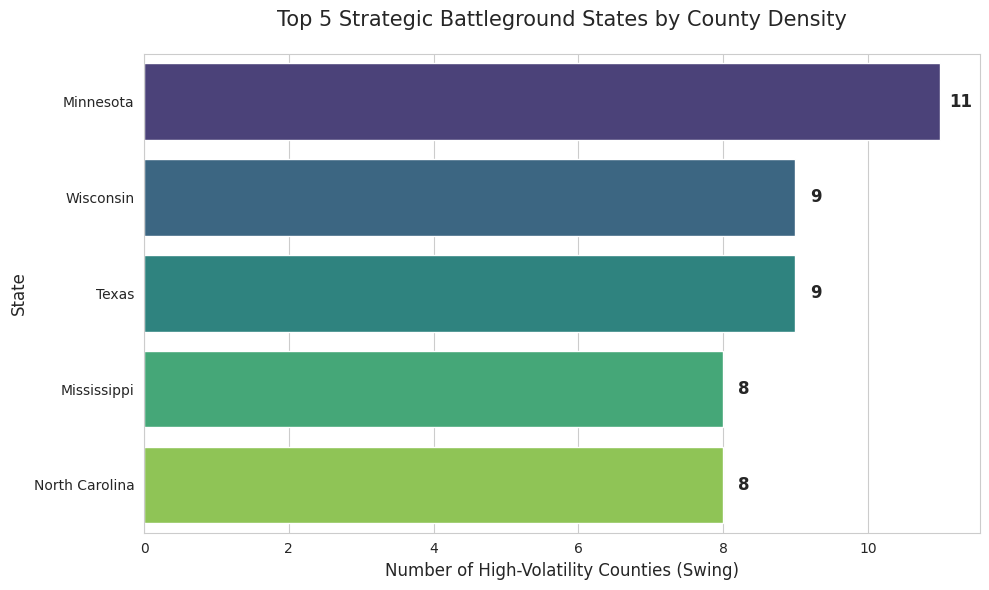

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Crear la gráfica de barras
# Usamos el state_ranking que ya calculaste
ax = sns.barplot(x='swing_count', y='state_name', data=state_ranking.head(5),
                 palette='viridis', hue='state_name', legend=False)

# 3. Etiquetas en Inglés para el Portafolio
plt.title('Top 5 Strategic Battleground States by County Density', fontsize=15, pad=20)
plt.xlabel('Number of High-Volatility Counties (Swing)', fontsize=12)
plt.ylabel('State', fontsize=12)

# 4. Añadir los valores al final de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'center', va = 'center',
                xytext = (15, 0),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('top_states_battleground.png', dpi=300)
plt.show()

In [8]:
# 1. Instalar el motor de exportación de imágenes (solo toma unos segundos)
!pip install -U kaleido

import plotly.express as px
import json
from urllib.request import urlopen
import os

# 2. Generar el mapa (Asegurándonos que df_swing está en memoria)
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

fig = px.choropleth(
    df_swing,
    geojson=counties,
    locations='county_fips',
    color='margen_perc',
    color_continuous_scale="RdBu",
    range_color=[-3, 3],
    scope="usa",
    hover_name='state_code',
    hover_data={'county_fips': True, 'TotalPop': True, 'margen_perc': True},
    title='<b>Strategic Portfolio Day 3: Battleground Clusters</b>'
)

# 3. Guardar en tu carpeta de Drive
folder_path = '/content/drive/MyDrive/Proyecto_Elecciones_EEUU/'

# Guardar HTML (Interactivo - Lo mejor para compartir)
fig.write_html(os.path.join(folder_path, 'mapa_interactivo_day3.html'))

# Guardar PNG (Estático - Lo mejor para el README de GitHub)
fig.write_image(os.path.join(folder_path, 'static_map_day3.png'), engine="kaleido")

print(f"✅ ¡Misión cumplida! Archivos exportados a Drive:")
print(f"1. Mapa Interactivo: {os.path.join(folder_path, 'mapa_interinteractive_day3.html')}")
print(f"2. Imagen para Reporte: {os.path.join(folder_path, 'static_map_day3.png')}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 3.1 MB/s eta 0:00:00


ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [9]:
import os

# 1. Definir ruta
folder_path = '/content/drive/MyDrive/Proyecto_Elecciones_EEUU/'

# 2. Guardar lo que SÍ funciona sin librerías extras
# Esto guarda el mapa interactivo (puedes abrirlo en cualquier navegador)
fig.write_html(os.path.join(folder_path, 'mapa_interactivo_day3.html'))

# 3. Guardar el CSV con los nombres de estados para no perder el trabajo de hoy
df_swing.to_csv(os.path.join(folder_path, 'df_dia3_final_geolocalizado.csv'), index=False)

print(f"✅ Archivos críticos guardados en: {folder_path}")
print("1. mapa_interactivo_day3.html")
print("2. df_dia3_final_geolocalizado.csv")

✅ Archivos críticos guardados en: /content/drive/MyDrive/Proyecto_Elecciones_EEUU/
1. mapa_interactivo_day3.html
2. df_dia3_final_geolocalizado.csv


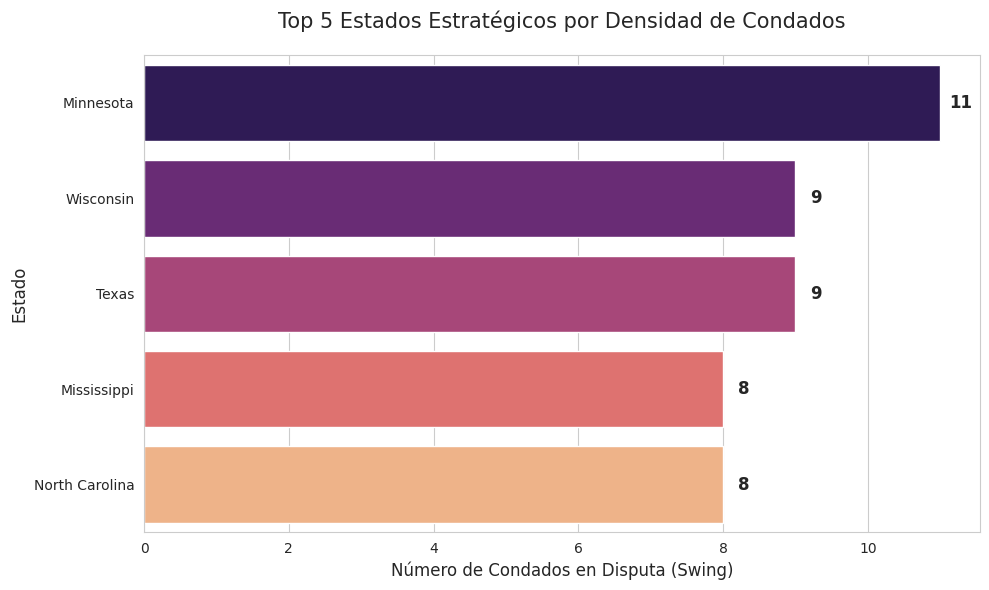

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Crear la gráfica
ax = sns.barplot(x='swing_count', y='state_name', data=state_ranking.head(5),
                 palette='magma', hue='state_name', legend=False)

# Títulos y etiquetas en ESPAÑOL
plt.title('Top 5 Estados Estratégicos por Densidad de Condados', fontsize=15, pad=20)
plt.xlabel('Número de Condados en Disputa (Swing)', fontsize=12)
plt.ylabel('Estado', fontsize=12)

# Añadir valores a las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha = 'center', va = 'center',
                xytext = (15, 0),
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/top_estados_espanol.png', dpi=300)
plt.show()

In [11]:
import plotly.express as px

# Generar el mapa con etiquetas en ESPAÑOL
fig_es = px.choropleth(
    df_swing,
    geojson=counties,
    locations='county_fips',
    color='margen_perc',
    color_continuous_scale="RdBu",
    range_color=[-3, 3],
    scope="usa",
    hover_name='state_name', # Ahora mostrará el nombre completo del estado
    hover_data={
        'county_fips': False,
        'TotalPop': True,
        'margen_perc': True
    },
    title='<b>Mapa de Clústeres Estratégicos: Puntos de Alta Volatilidad</b>',
    labels={
        'margen_perc': 'Margen (%)',
        'TotalPop': 'Población Total',
        'state_name': 'Estado'
    }
)

fig_es.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# Guardar versiones en español
fig_es.write_html('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/mapa_interactivo_espanol.html')
fig_es.write_image('/content/drive/MyDrive/Proyecto_Elecciones_EEUU/mapa_estatico_espanol.png', engine="kaleido")

fig_es.show()

ValueError: Value of 'hover_name' is not the name of a column in 'data_frame'. Expected one of ['county_fips', 'TotalPop', 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'DEMOCRAT', 'GREEN', 'LIBERTARIAN', 'OTHER', 'REPUBLICAN', 'votos_totales_dr', 'margen_perc', 'segmento_electoral', 'distancia_al_cero', 'state_code'] but received: state_name

In [12]:
import plotly.express as px
import os

# 1. Crear formalmente la columna 'state_name' en tu DataFrame principal
# Usamos el diccionario fips_to_state que ya tienes (o lo definimos rápido aquí)
fips_to_state = {
    '01': 'Alabama', '04': 'Arizona', '05': 'Arkansas', '06': 'California', '08': 'Colorado',
    '12': 'Florida', '13': 'Georgia', '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
    '21': 'Kentucky', '22': 'Louisiana', '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi',
    '29': 'Missouri', '31': 'Nebraska', '34': 'New Jersey', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '42': 'Pennsylvania', '45': 'South Carolina', '47': 'Tennessee',
    '48': 'Texas', '51': 'Virginia', '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin'
}

# Extraemos el código de estado de los FIPS y mapeamos el nombre
df_swing['state_code'] = df_swing['county_fips'].str[:2]
df_swing['state_name'] = df_swing['state_code'].map(fips_to_state)

# 2. Ahora sí, generar el mapa con etiquetas en ESPAÑOL
fig_es = px.choropleth(
    df_swing,
    geojson=counties,
    locations='county_fips',
    color='margen_perc',
    color_continuous_scale="RdBu",
    range_color=[-3, 3],
    scope="usa",
    hover_name='state_name', # Ahora la columna sí existe
    hover_data={
        'county_fips': False,
        'TotalPop': True,
        'margen_perc': True
    },
    title='<b>Mapa de Clústeres Estratégicos: Puntos de Alta Volatilidad</b>',
    labels={
        'margen_perc': 'Margen (%)',
        'TotalPop': 'Población Total',
        'state_name': 'Estado'
    }
)

fig_es.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# 3. Guardar versiones en español en Drive
folder_path = '/content/drive/MyDrive/Proyecto_Elecciones_EEUU/'
fig_es.write_html(os.path.join(folder_path, 'mapa_interactivo_espanol.html'))
fig_es.write_image(os.path.join(folder_path, 'mapa_estatico_espanol.png'), engine="kaleido")

fig_es.show()

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [13]:
# 1. Re-instalación forzada de kaleido
!pip install -U kaleido

import plotly.express as px
import json
from urllib.request import urlopen
import os
import pandas as pd

# 2. Cargar geometría (necesaria para el mapa)
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties = json.load(response)

# 3. Asegurar que la columna 'state_name' existe en df_swing
fips_to_state = {
    '01': 'Alabama', '04': 'Arizona', '05': 'Arkansas', '06': 'California', '08': 'Colorado',
    '12': 'Florida', '13': 'Georgia', '17': 'Illinois', '18': 'Indiana', '19': 'Iowa',
    '21': 'Kentucky', '22': 'Louisiana', '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi',
    '29': 'Missouri', '31': 'Nebraska', '34': 'New Jersey', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '42': 'Pennsylvania', '45': 'South Carolina', '47': 'Tennessee',
    '48': 'Texas', '51': 'Virginia', '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin'
}
df_swing['state_code'] = df_swing['county_fips'].str[:2]
df_swing['state_name'] = df_swing['state_code'].map(fips_to_state)

# 4. Generar el Mapa en Español
fig_es = px.choropleth(
    df_swing,
    geojson=counties,
    locations='county_fips',
    color='margen_perc',
    color_continuous_scale="RdBu",
    range_color=[-3, 3],
    scope="usa",
    hover_name='state_name',
    hover_data={'county_fips': False, 'TotalPop': True, 'margen_perc': True},
    title='<b>Mapa de Clústeres Estratégicos: Puntos de Alta Volatilidad</b>',
    labels={'margen_perc': 'Margen (%)', 'TotalPop': 'Población Total', 'state_name': 'Estado'}
)
fig_es.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

# 5. Guardar en Drive
folder_path = '/content/drive/MyDrive/Proyecto_Elecciones_EEUU/'

# Guardamos el HTML (Este siempre funciona y es el mejor para el portafolio)
fig_es.write_html(os.path.join(folder_path, 'mapa_interactivo_espanol.html'))

# Intentamos guardar el PNG (Si kaleido falla, puedes tomar captura al mapa que saldrá abajo)
try:
    fig_es.write_image(os.path.join(folder_path, 'mapa_estatico_espanol.png'), engine="kaleido")
    print("✅ Imagen PNG guardada exitosamente.")
except Exception as e:
    print("⚠️ Nota: No se pudo exportar el PNG automáticamente, pero el HTML ya está en tu Drive.")
    print("💡 Sugerencia: Toma una captura de pantalla al mapa que aparece abajo para tu informe.")

fig_es.show()

Output hidden; open in https://colab.research.google.com to view.